In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

In [2]:
titanic = pd.read_csv("./titanic_toy.csv")
titanic.sample(10)

,Age,Fare,Family,Survived
594,37.0,26.0000,1,0
634,9.0,27.9000,5,0
359,NaN,7.8792,0,1
121,NaN,8.0500,0,0
269,35.0,135.6333,0,1
583,36.0,40.1250,0,0
221,27.0,13.0000,0,0
197,42.0,8.4042,1,0
280,65.0,7.7500,0,0
622,20.0,15.7417,2,1


In [9]:
x = titanic.iloc[::, :3:]
y = titanic.iloc[::, -1]

In [10]:
titanic.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [11]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

In [15]:
x_train.sample(5)

,Age,Fare,Family
262,52.0,79.6500,2
102,21.0,77.2875,1
460,48.0,26.5500,0
705,39.0,26.0000,0
99,34.0,26.0000,1


In [20]:
mean_age = x_train["Age"].mean()
mean_fare = x_train["Fare"].mean()

median_age = x_train["Age"].median()
median_fare = x_train["Fare"].median()

In [22]:
x_train["Age_Mean"] = x_train["Age"].fillna(mean_age)
x_train["Fare_Mean"] = x_train["Fare"].fillna(mean_fare)

x_train["Age_Median"] = x_train["Age"].fillna(median_age)
x_train["Fare_Median"] = x_train["Fare"].fillna(median_fare)

x_train.sample(10)

,Age,Fare,Family,Age_Mean,Fare_Mean,Age_Median,Fare_Median
615,24.0,65.0000,3,24.000000,65.000000,24.0,65.0000
689,15.0,211.3375,1,15.000000,211.337500,15.0,211.3375
703,25.0,7.7417,0,25.000000,7.741700,25.0,7.7417
717,27.0,10.5000,0,27.000000,10.500000,27.0,10.5000
431,NaN,16.1000,1,29.498846,16.100000,28.0,16.1000
454,NaN,8.0500,0,29.498846,8.050000,28.0,8.0500
860,41.0,NaN,2,41.000000,32.517788,41.0,14.4000
681,27.0,76.7292,0,27.000000,76.729200,27.0,76.7292
140,NaN,15.2458,2,29.498846,15.245800,28.0,15.2458
756,28.0,7.7958,0,28.000000,7.795800,28.0,7.7958


In [24]:
print(f"Age Variance: {x_train["Age"].var()}")
print(f"Age_Mean Variance: {x_train["Age_Mean"].var()}")
print(f"Age_Median Variance: {x_train["Age_Median"].var()}")

print(f"Fare variance: {x_train["Fare"].var()}")
print(f"Fare_Mean variance: {x_train["Fare_Mean"].var()}")
print(f"Fare_Median variance: {x_train["Fare_Median"].var()}")

Age Variance: 210.2517072477435
Age_Mean Variance: 168.85193366872227
Age_Median Variance: 169.20731007048155
Fare variance: 2761.0314349486343
Fare_Mean variance: 2621.232374951235
Fare_Median variance: 2637.012481677765


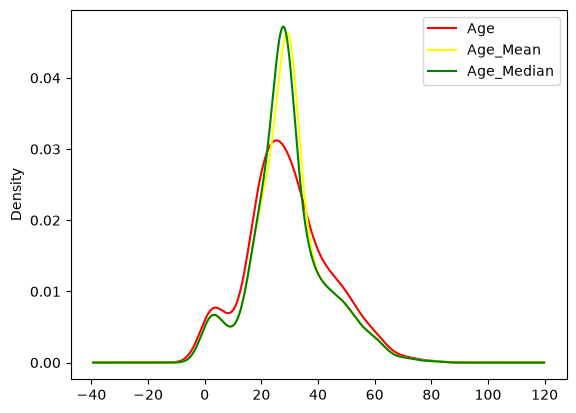

In [25]:
x_train["Age"].plot.density(color= "red")
x_train["Age_Mean"].plot.density(color= "yellow")
x_train["Age_Median"].plot.density(color= "green")

plt.legend(["Age", "Age_Mean", "Age_Median"])
plt.show()

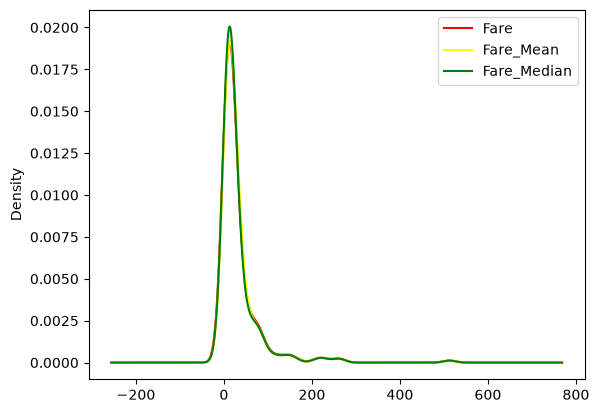

In [26]:
x_train["Fare"].plot.density(color= "red")
x_train["Fare_Mean"].plot.density(color= "yellow")
x_train["Fare_Median"].plot.density(color= "green")

plt.legend(["Fare", "Fare_Mean", "Fare_Median"])
plt.show()

In [ ]:
# Co-Variance

x_train.cov()

,Age,Fare,Family,Age_Mean,Fare_Mean,Age_Median,Fare_Median
Age,210.251707,75.481375,-6.993325,210.251707,71.193767,210.251707,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,2761.031435,63.938058,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,17.657433,-5.587710,17.672035
Age_Mean,210.251707,60.224654,-5.616299,168.851934,57.175304,168.851934,56.282518
Fare_Mean,71.193767,2761.031435,17.657433,57.175304,2621.232375,60.700688,2621.232375
Age_Median,210.251707,63.938058,-5.587710,168.851934,60.700688,169.207310,59.728510
Fare_Median,70.082085,2761.031435,17.672035,56.282518,2621.232375,59.728510,2637.012482


In [28]:
# Co-Relation

x_train.corr()

,Age,Fare,Family,Age_Mean,Fare_Mean,Age_Median,Fare_Median
Age,1.000000,0.091482,-0.319651,1.000000,0.088944,1.000000,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,1.000000,0.093496,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,0.204981,-0.255307,0.204536
Age_Mean,1.000000,0.088151,-0.256883,1.000000,0.085941,0.998949,0.084346
Fare_Mean,0.088944,1.000000,0.204981,0.085941,1.000000,0.091145,0.997003
Age_Median,1.000000,0.093496,-0.255307,0.998949,0.091145,1.000000,0.089416
Fare_Median,0.087232,1.000000,0.204536,0.084346,0.997003,0.089416,1.000000


<Axes: >

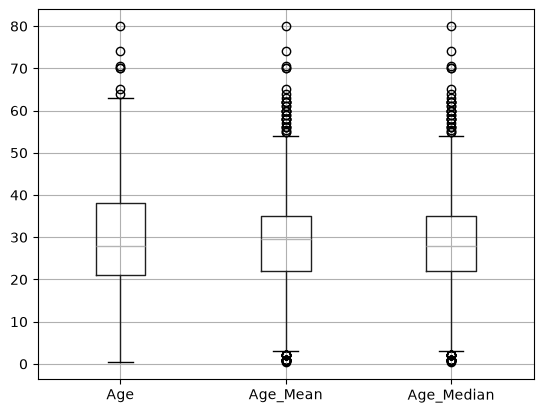

In [29]:
x_train[["Age", "Age_Mean", "Age_Median"]].boxplot()

<Axes: >

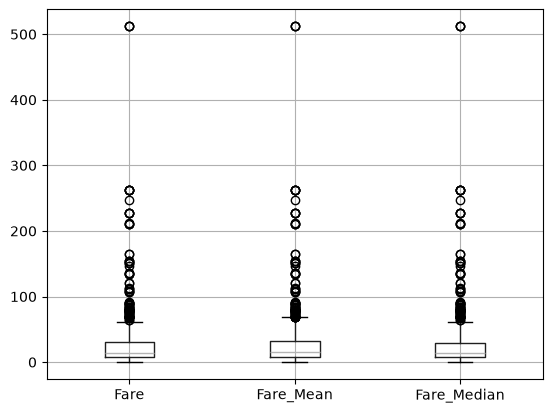

In [30]:
x_train[["Fare", "Fare_Mean", "Fare_Median"]].boxplot()

In [34]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

imp_mean = skl.impute.SimpleImputer(strategy= "mean")
imp_median= skl.impute.SimpleImputer(strategy= "median")

In [36]:
trf = skl.compose.ColumnTransformer([
    ("imp_mean", imp_mean, ["Age"]),
    ("imp_median", imp_median, ["Fare"])
    ], remainder= "passthrough")

trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imp_mean', ...), ('imp_median', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [37]:
trf.named_transformers_["imp_mean"].statistics_

array([29.49884615])

In [38]:
trf.named_transformers_["imp_median"].statistics_

array([14.4])

In [39]:
x_train_trf = trf.transform(x_train)
x_test_trf = trf.transform(x_test)

In [40]:
x_train_trf

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))